# Dependence of variance of alpha estimate vs 1/T and H

In [1]:
!pip install --no-deps stochastic


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 1.8 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:

import numpy as np
from sklearn.metrics import mean_absolute_error


In [4]:
"""
This module have been implemented to compute an Hurst exponent
Estimator using maximum of likelyhood on the periodogram.
It is not a log regression as in Hest_Welp
the  periodogram is the one given by the scipy library
these functions hab been made according to whittlenew,
wittlefunc and fspecFGN of Matlab Biyu_code
"""
import numpy as np
import scipy.optimize as so
from math import gamma


def whittle(data):
    """This function compute the Hurst exponent of a signal using
    a maximum of likelihood on periodogram
    """
    nbpoints = len(data)
    nhalfm = int((nbpoints - 1) / 2)
    tmp = np.abs(np.fft.fft(data))
    gammahat = np.exp(2 * np.log(tmp[1:nhalfm + 1])) / (2 * np.pi * nbpoints)
    func = lambda Hurst: whittlefunc(Hurst, gammahat, nbpoints)
    return so.fminbound(func, 0, 1)


def whittle_t(data, pointeur, idx):
    """This function compute the Hurst exponent of a signal using
    a maximum of likelihood on periodogram
    the return happend in pointeur[idx]
    """
    nbpoints = len(data)
    nhalfm = int((nbpoints - 1) / 2)
    tmp = np.abs(np.fft.fft(data))
    gammahat = np.exp(2 * np.log(tmp[1:nhalfm + 1])) / (2 * np.pi * nbpoints)
    func = lambda Hurst: whittlefunc(Hurst, gammahat, nbpoints)
    pointeur[idx] = so.fminbound(func, 0, 1)


def whittle_s(data, idx):
    """This function compute the Hurst exponent of a signal data[idx,:]
    using a maximum of likelihood on welch periodogram
    """
    dataidx = data[idx, :]
    nbpoints = len(dataidx)
    nhalfm = int((nbpoints - 1) / 2)
    tmp = np.abs(np.fft.fft(dataidx))
    gammahat = np.exp(2 * np.log(tmp[1:nhalfm + 1])) / (2 * np.pi * nbpoints)
    func = lambda Hurst: whittlefunc(Hurst, gammahat, nbpoints)
    return so.fminbound(func, 0, 1)


def whittle_norm_s(data, idx):
    """This function compute the Hurst exponent of a signal data[idx,:]
    using a maximum of likelihood on periodogram
    the data are normalized which does'nt change anything !
    """
    dataidx = data[idx, :]
    nbpoints = len(dataidx)
    datanorm = (dataidx - np.mean(dataidx)) / np.var(dataidx)
    nhalfm = int((nbpoints - 1) / 2)
    tmp = np.abs(np.fft.fft(datanorm))
    gammahat = np.exp(2 * np.log(tmp[1:nhalfm + 1])) / (2 * np.pi * nbpoints)
    func = lambda Hurst: whittlefunc(Hurst, gammahat, nbpoints)
    return so.fminbound(func, 0, 1)


def whittlefunc(hurst, gammahat, nbpoints):
    """This is the Whittle function
    """
    gammatheo = fspec_fgn(hurst, nbpoints)
    qml = gammahat / gammatheo
    return 2 * (2 * np.pi / nbpoints) * np.sum(qml)


def fspec_fgn(hest, nbpoints):
    """This is the spectral density of a fGN of Hurst exponent hest
    """
    hhest = - ((2 * hest) + 1)
    const = np.sin(np.pi * hest) * gamma(- hhest) / np.pi
    nhalfm = int((nbpoints - 1) / 2)
    dpl = 2 * np.pi * np.arange(1, nhalfm + 1) / nbpoints
    fspec = np.ones(nhalfm)
    for i in np.arange(0, nhalfm):
        dpfi = np.arange(0, 200)
        dpfi = 2 * np.pi * dpfi
        fgi = (np.abs(dpl[i] + dpfi)) ** hhest
        fhi = (np.abs(dpl[i] - dpfi)) ** hhest
        dpfi = fgi + fhi
        dpfi[0] = dpfi[0] / 2
        dpfi = (1 - np.cos(dpl[i])) * const * dpfi
        fspec[i] = np.sum(dpfi)
    fspec = fspec / np.exp(2 * np.sum(np.log(fspec)) / nbpoints)
    return fspec

In [5]:
import numpy as np

class Tamsd:
    def __init__(self, use_correction=False, trim_percent=0, is_increments=False, return_TEA=False):
        """
        Ініціалізація класу Tamsd.
        Args:
            use_correction (bool): Чи застосовувати корекцію TEA-MSD&variance. За замовчуванням False.
            trim_percent (int): Відсоток найбільших значень для обрізання. За замовчуванням 0.
            is_increments (bool): Чи дані є інкрементами. Якщо False, дані є позиціями (кумулятивними рядами).
            return_TEA (bool): Чи повертати TEA exponent замість batch exponents.
        """
        self.use_correction = use_correction
        self.trim_percent = trim_percent
        self.is_increments = is_increments
        self.return_TEA = return_TEA

    @staticmethod
    def trim_array1s(arr, percent):
        """
        Видаляє заданий відсоток найбільших значень з кожного рядка 2D масиву, ігноруючи NaN.
        
        Args:
            arr (np.ndarray): Вхідний 2D масив.
            percent (float): Відсоток значень для видалення (0 <= percent < 100).
        Returns:
            np.ndarray: Масив зі значеннями вище порогу, заміненими на NaN.
        """
        if percent == 0:
            return arr
        
        result = arr.copy()
        for i in range(arr.shape[0]):
            row = arr[i]
            valid_mask = ~np.isnan(row)
            valid_values = row[valid_mask]
            
            if len(valid_values) == 0:
                continue
            
            k = int(np.round(len(valid_values) * (percent / 100.0)))
            
            if k > 0:
                # Сортуємо валідні значення і знаходимо поріг
                sorted_valid = np.sort(valid_values)
                threshold = sorted_valid[-k]
                # Замінюємо значення вище порогу на NaN
                result[i] = np.where(row < threshold, row, np.nan)
        
        return result

    @staticmethod
    def trim_array1s_tea(arr, percent):
        """
        Видаляє заданий відсоток найбільших значень з усього масиву, ігноруючи NaN.
        Кількість елементів для видалення базується на всіх не-NaN значеннях.
        Args:
            arr (np.ndarray): Вхідний масив.
            percent (float): Відсоток значень для видалення (0 <= percent < 100).
        Returns:
            np.ndarray: Масив зі значеннями вище порогу, заміненими на NaN.
        """
        if percent == 0:
            return arr
        
        valid_mask = ~np.isnan(arr)
        valid_values = arr[valid_mask]
        
        if len(valid_values) == 0:
            return arr
        
        k = int(np.round(len(valid_values) * (percent / 100.0)))
        
        if k == 0:
            return arr
        
        # Сортуємо валідні значення і знаходимо поріг
        sorted_valid = np.sort(valid_values)
        threshold = sorted_valid[-k]
        # Замінюємо значення вище порогу на NaN
        result = np.where(arr < threshold, arr, np.nan)
        
        return result

    def normalize_distribution(self, arr, target_mean, T):
        """
        Нормалізація розподілу з корекцією.
        Args:
            arr (np.ndarray): Вхідний масив.
            target_mean (float): Цільове середнє значення.
            T (float): Ефективний час/індикатор кількості.
        Returns:
            np.ndarray: Нормалізований масив.
        """
        current_mean = np.nanmean(arr)
        current_std = np.nanstd(arr)
        adjustment_term = np.maximum(current_std**2 - 0.92 / T, 0)**0.5
        standardized = (arr - current_mean) / (current_std + 1e-8)
        return standardized * adjustment_term + target_mean

    def __call__(self, inputs):
        """
        Обчислення альфа (показника Херста).
        Args:
            inputs (np.ndarray): Вхідний масив форми (batch_size, timesteps, input_channels).
                                 Якщо is_increments=False, це позиції (кумулятивні ряди).
                                 Якщо is_increments=True, це інкременти.
        Returns:
            np.ndarray: Оцінені значення H (показник Херста).
        """
        # Визначаємо, працюємо з позиціями чи інкрементами
        if self.is_increments:
            # Якщо дані є інкрементами, перетворюємо їх на позиції (кумулятивні суми)
            # Припускаємо, що початкова позиція = 0
            positions = np.concatenate([np.zeros((inputs.shape[0], 1, inputs.shape[2])), 
                                       np.cumsum(inputs, axis=1)], axis=1)
        else:
            # Дані вже є позиціями
            positions = inputs
        
        batch_size = positions.shape[0]
        timesteps = positions.shape[1]
        input_channels = positions.shape[2]

        # Підрахунок не-NaN елементів
        not_nan_mask = ~np.isnan(positions)
        not_nan_count = np.sum(not_nan_mask)

        epsilon = 0
        max_lag = 4
        msds = []
        teamsd_list = []

        # --- Обчислення MSD та TEA-MSD ---
        for lag in range(1, max_lag + 1):
            # Обчислюємо квадрати зміщень: (position[t+lag] - position[t])^2
            # Це еквівалентно підходу в реалізації 2
            displacements = positions[:, lag:, :] - positions[:, :-lag, :]
            squared_displacements = np.square(displacements)
            squared_displacements_sum = np.sum(squared_displacements, axis=2)

            # Для MSD – обрізаємо кожен рядок
            msd = np.nanmean(
                self.trim_array1s(squared_displacements_sum, self.trim_percent),
                axis=1
            )
            msds.append(msd)

            # Для TEA-MSD – обрізаємо масив цілком
            teamsd_lag = np.nanmean(
                self.trim_array1s_tea(squared_displacements_sum, self.trim_percent)
            )
            teamsd_list.append(teamsd_lag)

        msds = np.stack(msds, axis=1)  # (batch_size, max_lag)
        teamsd = np.array(teamsd_list)  # (max_lag,)

        t_lags = np.arange(1, max_lag + 1, dtype=np.float32)

        
        if self.return_TEA:

            if not np.any(np.isnan(teamsd)):
                alpha = np.clip(np.polyfit(np.log(t_lags), np.log(teamsd), deg = 1)[0], 0.001, 1.999)
                # print(idx, np.log(row))
            else:
                alpha = np.NaN
                # print('-')
            
    
            # --- Обмеження alpha до валідного діапазону ---
            alpha = np.clip(alpha, 0.0001, 1.999) 
            return alpha   
        
        alpha = np.zeros(batch_size, dtype= float) 
        for idx, row in enumerate(msds):
            if not np.any(np.isnan(row)):
                alpha[idx] = np.polyfit(np.log(t_lags), np.log(row), deg = 1)[0]
                # print(idx, np.log(row))
            else:
                alpha[idx] = np.NaN
                # print('-')
        
        # --- Обмеження alpha до валідного діапазону ---        
        alpha = np.clip(alpha, 0.0001, 1.999) 
        # last_msd = msds[:, -1]  # (batch_size,)
        # mask_nan = last_msd < 1e-6
        # alpha = np.where(mask_nan, np.nan, alpha)
        # alpha = np.where(mask_nan, 1.0, alpha) # використати для уникненн NaN
        # alpha = np.nan_to_num(alpha, nan=1.0) # використати для уникненн NaN
        
        return alpha

# TA-MSD Test on FBM Dataset

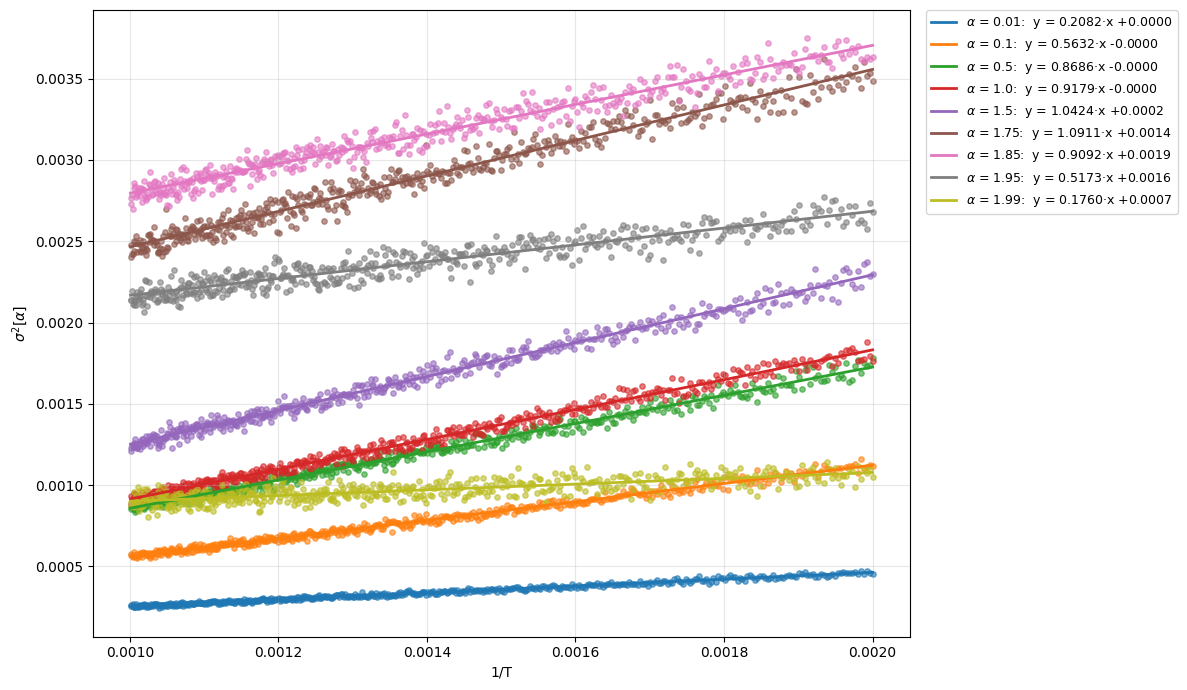

alpha = 0.01:  slope = 0.2082,  intercept = 0.0000
alpha = 0.10:  slope = 0.5632,  intercept = -0.0000
alpha = 0.50:  slope = 0.8686,  intercept = -0.0000
alpha = 1.00:  slope = 0.9179,  intercept = -0.0000
alpha = 1.50:  slope = 1.0424,  intercept = 0.0002
alpha = 1.75:  slope = 1.0911,  intercept = 0.0014
alpha = 1.85:  slope = 0.9092,  intercept = 0.0019
alpha = 1.95:  slope = 0.5173,  intercept = 0.0016
alpha = 1.99:  slope = 0.1760,  intercept = 0.0007
All alpha:    slope = 0.6993,  intercept = 0.0007


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from stochastic.processes.continuous import FractionalBrownianMotion
from sklearn.linear_model import LinearRegression          # ← новая регрессия
from sklearn.metrics import mean_squared_error

# ---------- генератор FBM-траекторий (N, T, 2) -------------------------------
def simulate_fbm_batch(T, n_traj, hurst):
    """
    FBM-траектории размера (n_traj, T, 2) с показателем Херста hurst.
    """
    T_int = int(T)
    trajs = np.empty((n_traj, T_int, 2), dtype=np.float64)

    for i in range(n_traj):
        fbm_x = FractionalBrownianMotion(hurst=hurst, t=T_int - 1)
        fbm_y = FractionalBrownianMotion(hurst=hurst, t=T_int - 1)

        # sample(T_int - 1) → T точек (0 … T-1)
        trajs[i, :, 0] = fbm_x.sample(T_int - 1)   # X
        trajs[i, :, 1] = fbm_y.sample(T_int - 1)   # Y 

    return trajs



def draw_plot():
    # Parameters -------------------------------------------------------------
    alpha_values = [0.01, 0.1, 0.5, 1.00, 1.5, 1.75, 1.85, 1.95, 1.99]
    alpha_values_plot = [0.01, 0.1, 0.5, 1.00, 1.5, 1.75, 1.85, 1.95, 1.99] 
    colours  = [
        'tab:blue',
        'tab:orange',
        'tab:green',
        'tab:red',
        'tab:purple',
        'tab:brown',
        'tab:pink',
        'tab:gray',
        'tab:olive'
    ]
    n_traj   = 5000
    T_values = np.arange(500, 1000)          # trajectory lengths
    inv_T    = 1.0 / T_values             # x-axis: 1/T

    msd_tool = Tamsd()                   # your TA-MSD analyser

    # Containers
    var_dict   = {}       # Var(alpha) for each H
    param_dict = {}       # (slope, intercept) for each H

    # --- individual regressions -------------------------------------------
    for alpha in alpha_values:
        variances = np.empty_like(inv_T)
        for k, T in enumerate(T_values):
            trajs   = simulate_fbm_batch(T, n_traj, alpha/2)   # shape (N, T, 2)
            alphas  = msd_tool(trajs)       # shape (N,)
            variances[k] = np.var(alphas, ddof=1)        # Var(alpha)

        model = LinearRegression()                       # intercept=True
        model.fit(inv_T.reshape(-1, 1), variances)

        var_dict[alpha]   = variances.copy()
        param_dict[alpha] = (model.coef_[0], model.intercept_)

    # --- joint regression (all H together) ---------------------------------
    all_x = np.tile(inv_T, len(alpha_values)).reshape(-1, 1)
    all_y = np.concatenate([var_dict[alpha] for alpha in alpha_values])
    joint_model = LinearRegression().fit(all_x, all_y)
    joint_slope  = joint_model.coef_[0]
    joint_inter  = joint_model.intercept_

    # --- plotting ----------------------------------------------------------
    plt.figure(figsize=(12, 7))

    for alpha, colour in zip(alpha_values_plot, colours):
        slope, inter = param_dict[alpha]
        plt.scatter(inv_T, var_dict[alpha], s=15, alpha=0.6, color=colour)
        plt.plot(inv_T, slope * inv_T + inter,
                 color=colour, lw=2,
                 label=rf'$\alpha$ = {alpha}:  y = {slope:.4f}·x {inter:+.4f}')


    plt.xlabel('1/T')
    plt.ylabel(r'$\sigma^2[\alpha]$')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=9)
    # plt.legend(frameon=False, fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- console summary ---------------------------------------------------
    for alpha in alpha_values:
        slope, inter = param_dict[alpha]
        print(f'alpha = {alpha:.2f}:  slope = {slope:.4f},  intercept = {inter:.4f}')
    print(f'All alpha:    slope = {joint_slope:.4f},  intercept = {joint_inter:.4f}')

draw_plot()

# Whittle Test on FBM Dataset

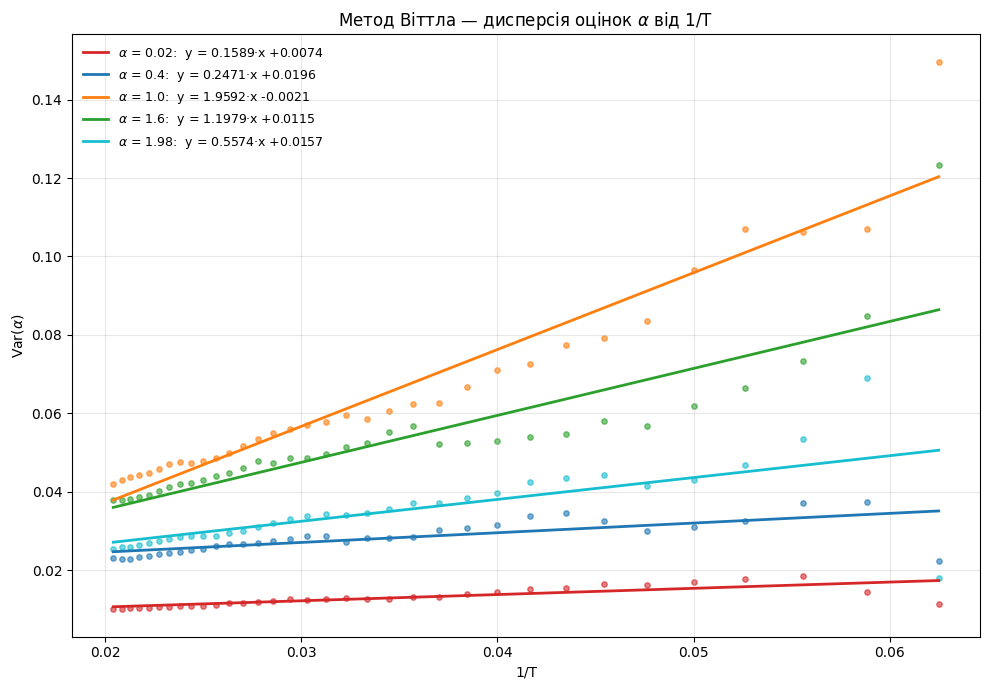

H = 0.01:  slope = 0.1589,  intercept = 0.0074
H = 0.10:  slope = 0.5062,  intercept = 0.0073
H = 0.20:  slope = 0.2471,  intercept = 0.0196
H = 0.35:  slope = 0.5121,  intercept = 0.0271
H = 0.50:  slope = 1.9592,  intercept = -0.0021
H = 0.65:  slope = 0.8209,  intercept = 0.0266
H = 0.80:  slope = 1.1979,  intercept = 0.0115
H = 0.90:  slope = 0.1804,  intercept = 0.0326
H = 0.99:  slope = 0.5574,  intercept = 0.0157
All H:    slope = 0.6822,  intercept = 0.0162


In [7]:
def draw_plot():
    # Parameters -------------------------------------------------------------
    H_values = [0.01, 0.1, 0.2, 0.35, 0.50, 0.65, 0.8, 0.9, 0.99]
    H_values_plot = [0.01,  0.2,  0.50,  0.8,  0.99]    
    colours  = ['tab:red', 'tab:blue', 'tab:orange', 'tab:green', 'tab:cyan']
    n_traj   = 10
    T_values = np.arange(16, 50)          # trajectory lengths
    inv_T    = 1.0 / T_values             # x-axis: 1/T

    
    # Containers
    var_dict   = {}       # Var(alpha) for each H
    param_dict = {}       # (slope, intercept) for each H

    # --- individual regressions -------------------------------------------
    for H in H_values:
        variances = np.empty_like(inv_T)
        alphas = []
        for k, T in enumerate(T_values):
            trajs   = simulate_fbm_batch(T, n_traj, H)   # shape (N, T, 2)
            dif = trajs[:,1:,:] - trajs[:,:-1,:]
            for tr in dif:
                alphas.append(whittle(tr[:,0]) +  whittle(tr[:,1]))      # shape (N,)
            variances[k] = np.var(alphas, ddof=1)        # Var(alpha)

        model = LinearRegression()                       # intercept=True
        model.fit(inv_T.reshape(-1, 1), variances)

        var_dict[H]   = variances.copy()
        param_dict[H] = (model.coef_[0], model.intercept_)

    # --- joint regression (all H together) ---------------------------------
    all_x = np.tile(inv_T, len(H_values)).reshape(-1, 1)
    all_y = np.concatenate([var_dict[h] for h in H_values])
    joint_model = LinearRegression().fit(all_x, all_y)
    joint_slope  = joint_model.coef_[0]
    joint_inter  = joint_model.intercept_

    # --- plotting ----------------------------------------------------------
    plt.figure(figsize=(10, 7))

    for H, colour in zip(H_values_plot, colours):
        slope, inter = param_dict[H]
        plt.scatter(inv_T, var_dict[H], s=15, alpha=0.6, color=colour)
        plt.plot(inv_T, slope * inv_T + inter,
                 color=colour, lw=2,
                 label=rf'$\alpha$ = {H*2}:  y = {slope:.4f}·x {inter:+.4f}')



    plt.xlabel('1/T')
    plt.ylabel(r'Var($\alpha$)')
    plt.title(r'Метод Віттла — дисперсія оцінок $\alpha$ від 1/T')
    plt.legend(frameon=False, fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- console summary ---------------------------------------------------
    for H in H_values:
        slope, inter = param_dict[H]
        print(f'H = {H:.2f}:  slope = {slope:.4f},  intercept = {inter:.4f}')
    print(f'All H:    slope = {joint_slope:.4f},  intercept = {joint_inter:.4f}')

draw_plot()